# 🛒 Shopper Spectrum

## Customer Segmentation and Product Recommendation System

### Author: Aditya Raj

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- K-Means Clustering
- RFM Analysis
- Collaborative Filtering

### Objective
To segment customers based on purchasing behavior and recommend products using transaction data.

# Dataset Collection and Understanding

The dataset contains retail transaction records including customer information, products purchased, quantities, prices, and transaction dates.

The goal is to analyze customer behavior and build a recommendation system.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded!")

All libraries loaded!


In [4]:
import pandas as pd
print(pd.__version__)


3.0.3


In [6]:
import os
print(os.getcwd())

/Users/adityathakur/Shopper_Spectrum


# Dataset Collection and Understanding

This dataset contains retail transaction records including:

- CustomerID
- InvoiceNo
- Description
- Quantity
- InvoiceDate
- UnitPrice
- Country

The objective is to analyze customer behavior and build customer segments.

In [7]:
import pandas as pd

df = pd.read_csv("data/online_retail copy 2.csv")

In [9]:
df.shape

(541909, 8)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


## Dataset Observations

- Dataset contains transaction-level data.
- CustomerID contains missing values.
- InvoiceDate is available for time-based analysis.
- Data cleaning is required before modeling.

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


# Data Cleaning

The following preprocessing steps are performed:

1. Remove missing CustomerID values
2. Remove cancelled transactions
3. Remove negative quantities
4. Remove invalid prices
5. Create TotalAmount feature

In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
df = df[df['Quantity'] > 0]

In [16]:
df = df[df['UnitPrice'] > 0]

## Cleaning Result

The dataset has been cleaned and prepared for exploratory analysis and machine learning.

In [17]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [18]:
print("Rows after cleaning:", len(df))

Rows after cleaning: 397884


In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


 # Exploratory Data Analysis (EDA)

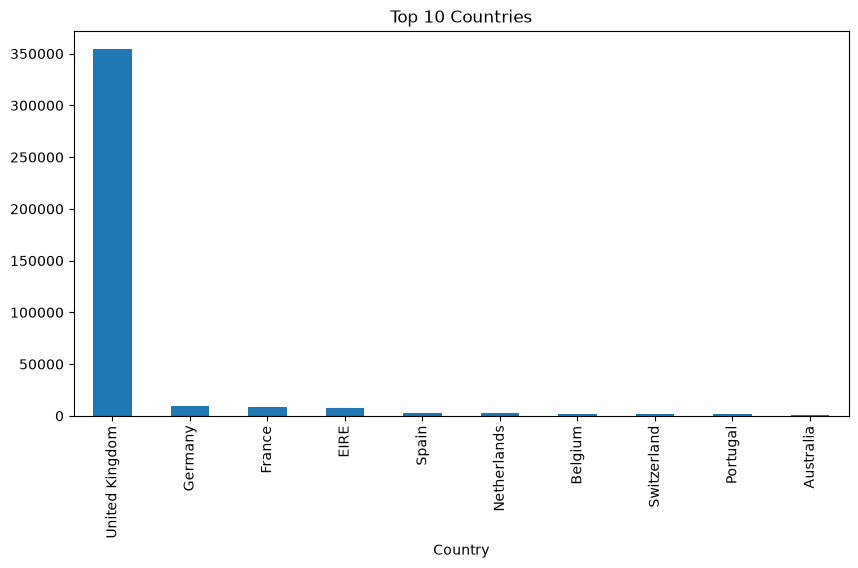

In [20]:
plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries')
plt.show()

### Insight

The majority of transactions originate from a limited number of countries, indicating concentrated customer demand.

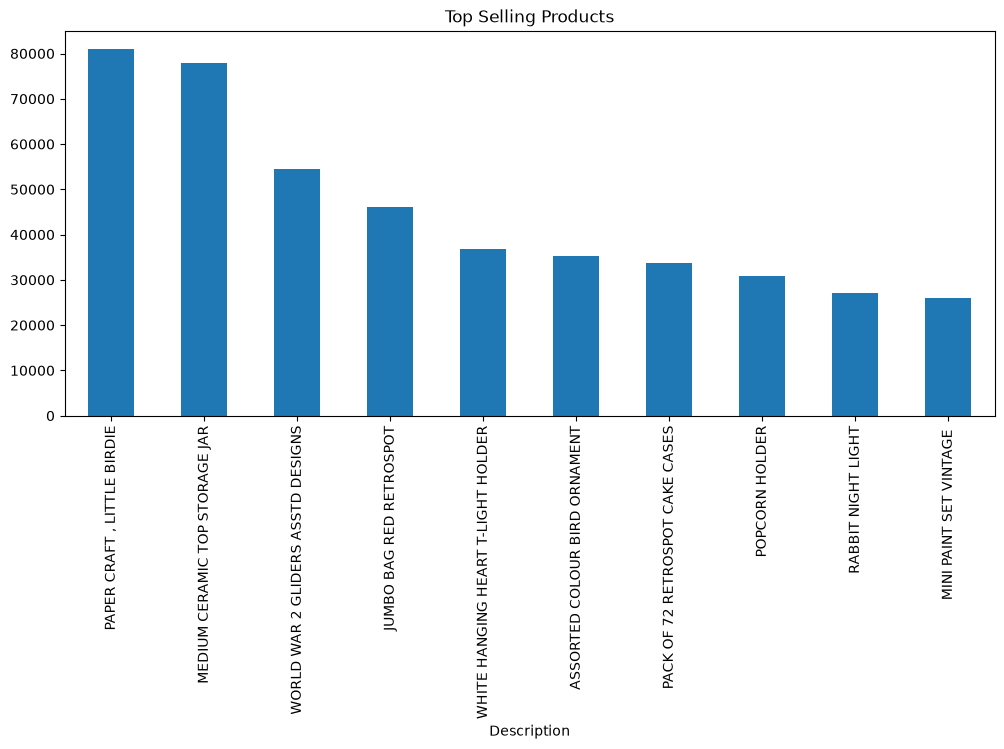

In [21]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title('Top Selling Products')
plt.show()

### Insight

A small group of products contributes significantly to total sales volume.

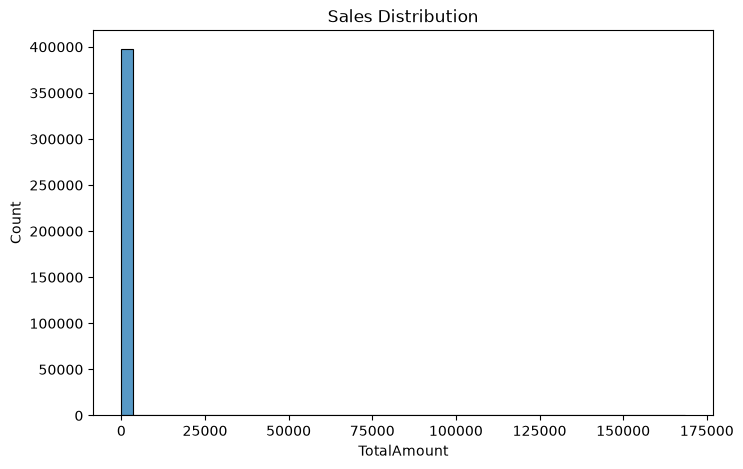

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalAmount'], bins=50)

plt.title('Sales Distribution')
plt.show()

### Insight

Most customers make small purchases, while a few customers generate very high sales.

In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

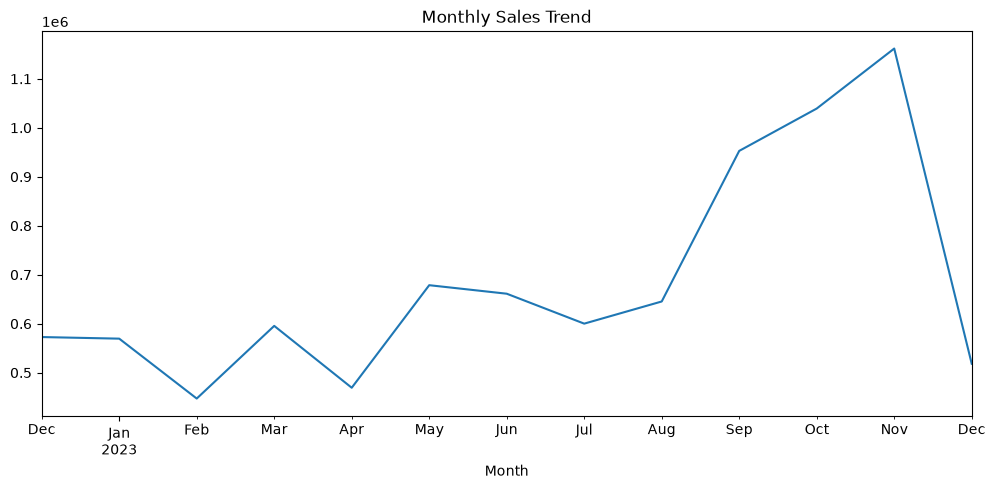

In [25]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Sales Trend')

plt.show()

### Insight

Monthly sales trends indicate seasonal purchasing behavior and changing demand patterns over time.

# RFM Analysis

RFM stands for:

- Recency
- Frequency
- Monetary

These metrics are used to evaluate customer value.

In [26]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-12-10 12:50:00


In [27]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## RFM Interpretation

- Lower Recency indicates recent purchases.
- Higher Frequency indicates loyal customers.
- Higher Monetary indicates valuable customers.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [30]:
rfm_scaled.shape

(4338, 3)

# Determining Optimal Clusters

The Elbow Method is used to identify the optimal number of customer segments.

In [31]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

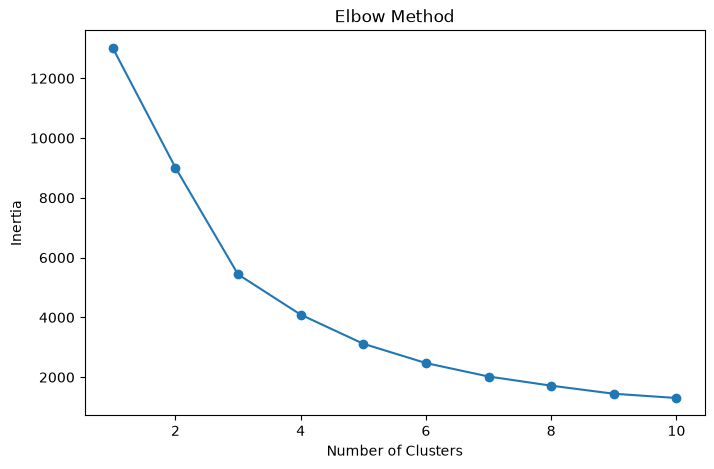

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

### Observation

The elbow point appears around K = 4, suggesting four meaningful customer groups.

# Customer Segmentation Using K-Means

In [33]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [55]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print(score)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
0.616212846765192


## Cluster Evaluation

Silhouette Score measures the quality of clustering.

A higher score indicates that customers are well separated into distinct groups with similar characteristics inside each cluster.

The obtained score suggests that the K-Means model successfully identified meaningful customer segments.

# Cluster Interpretation

## Cluster 0 - Regular Customers
Moderate spending and purchasing frequency.

## Cluster 1 - At-Risk Customers
Low activity and low spending.

## Cluster 2 - VIP Customers
Highest spending and frequency.

## Cluster 3 - Loyal Customers
Frequent and valuable buyers.

In [34]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [35]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


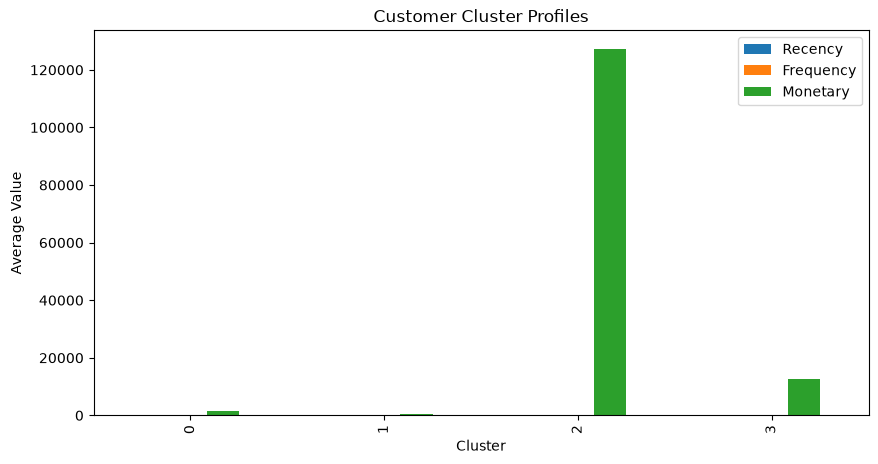

In [57]:
cluster_summary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Customer Cluster Profiles")
plt.ylabel("Average Value")
plt.show()

In [ ]:
cluster_summary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Cluster Profiles")
plt.show()

### Cluster Profile Insight

The chart compares Recency, Frequency, and Monetary values across all customer segments.

VIP and Loyal customers demonstrate higher purchase frequency and spending compared to Regular and At-Risk customers.

## Customer Segmentation Visualization

The scatter plot visualizes customer segments generated using K-Means clustering.

- X-axis: Frequency of purchases
- Y-axis: Monetary value
- Colors represent different customer clusters

This visualization helps identify high-value and low-value customer groups.

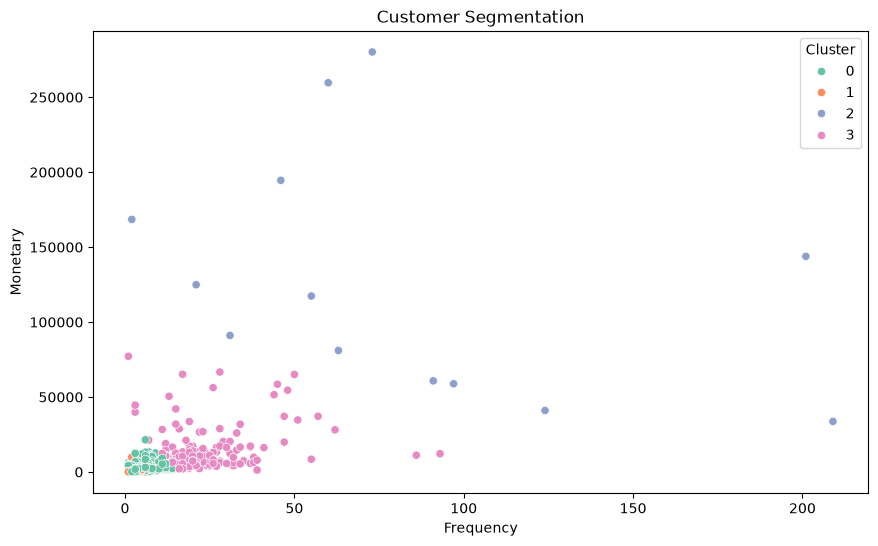

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title('Customer Segmentation')

plt.show()

### Segmentation Insight

The visualization shows distinct customer groups with different purchasing behaviors.

Some customers exhibit high purchase frequency and spending, while others show lower engagement levels. These insights can be used for targeted marketing and customer retention strategies.

# Model Saving

The trained K-Means model is saved for future deployment.

In [37]:
import joblib

joblib.dump(kmeans, 'models/kmeans_model.pkl')

['models/kmeans_model.pkl']

In [38]:
import os

os.listdir('models')

['kmeans_model.pkl', 'customer_segments.csv']

# Customer Segmentation Insights

The customers were segmented using RFM Analysis and K-Means Clustering.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer purchases.
- Monetary measures total customer spending.

The clustering approach helps identify valuable customers, loyal customers, and customers requiring re-engagement.

In [39]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

basket = (basket > 0).astype(int)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
rfm.to_csv('models/customer_segments.csv')

In [41]:
product_sales = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_sales

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

# Product Recommendation System

Item-based collaborative filtering is used to recommend similar products based on purchasing behavior.

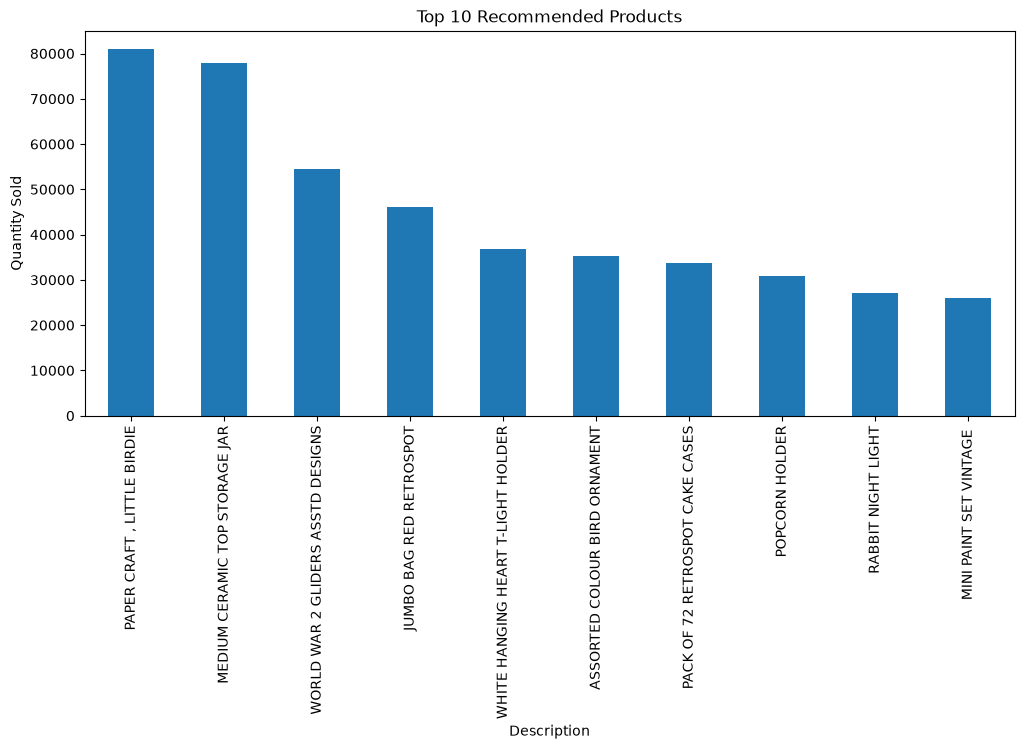

In [42]:
plt.figure(figsize=(12,5))

product_sales.plot(kind='bar')

plt.title('Top 10 Recommended Products')
plt.ylabel('Quantity Sold')

plt.show()

### Recommendation Insight

Products frequently purchased together can be recommended to customers to improve engagement and increase sales.

# Popular Product Analysis

In [56]:
print("Total Cleaned Records:", len(df))
print("Total Customers:", rfm.shape[0])

Total Cleaned Records: 397884
Total Customers: 4338


# Final Results

- Total Cleaned Records: 397,884
- Number of Customers Segmented: 4,338
- Number of Clusters: 4

Customer

# Advanced Product Recommendation

This section implements Item-Based Collaborative Filtering using Cosine Similarity to identify similar products based on customer purchasing patterns.

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

In [46]:
customer_product = pd.crosstab(
    df['CustomerID'],
    df['Description']
)

customer_product.shape

(4338, 3877)

In [47]:
similarity_matrix = cosine_similarity(customer_product.T)

In [48]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=customer_product.columns,
    columns=customer_product.columns
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.008116,0.013762,0.000000,0.000000,0.012915,0.000000,0.018580,0.008615,...,0.0,0.027524,0.040053,0.042898,0.0,0.047034,0.0,0.026508,0.000000,0.055048
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.039291,0.047587,0.000000,0.031524,0.053591,0.354585,0.034265,0.131066,...,0.0,0.038069,0.036933,0.035600,0.0,0.077252,0.0,0.032081,0.000000,0.019035
DOLLY GIRL BEAKER,0.008116,0.039291,1.000000,0.159729,0.300965,0.030523,0.098012,0.038147,0.063589,0.184588,...,0.0,0.012287,0.035760,0.141709,0.0,0.146974,0.0,0.068041,0.017376,0.061434
I LOVE LONDON MINI BACKPACK,0.013762,0.047587,0.159729,1.000000,0.204124,0.051755,0.097758,0.055442,0.154700,0.156492,...,0.0,0.062500,0.050528,0.045458,0.0,0.080102,0.0,0.075241,0.000000,0.062500
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.300965,0.204124,1.000000,0.000000,0.000000,0.000000,0.000000,0.191663,...,0.0,0.000000,0.000000,0.063628,0.0,0.130806,0.0,0.147442,0.000000,0.000000


In [52]:
def recommend_products(product_name, n=5):

    similar_products = similarity_df[product_name] \
        .sort_values(ascending=False)[1:n+1]

    return similar_products

In [50]:
print(customer_product.columns[:20])

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' 50'S CHRISTMAS GIFT BAG LARGE',
       ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK',
       ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY',
       ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE',
       ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET',
       ' TOADSTOOL BEDSIDE LIGHT ', ' TRELLIS COAT RACK',
       '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS',
       '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD',
       '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS',
       '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND'],
      dtype='str', name='Description')


In [53]:
recommend_products('10 COLOUR SPACEBOY PEN')

Description
SPACEBOY BIRTHDAY CARD       0.374712
PIN CUSHION BABUSHKA PINK    0.371725
SCOTTIE DOGS BABY BIB        0.368553
DOTCOM POSTAGE               0.362515
CARD DOLLY GIRL              0.360705
Name: 10 COLOUR SPACEBOY PEN, dtype: float64

## Product Recommendation Results

The recommendation engine identifies products that are frequently purchased by similar customers. This helps businesses recommend relevant products and increase cross-selling opportunities.

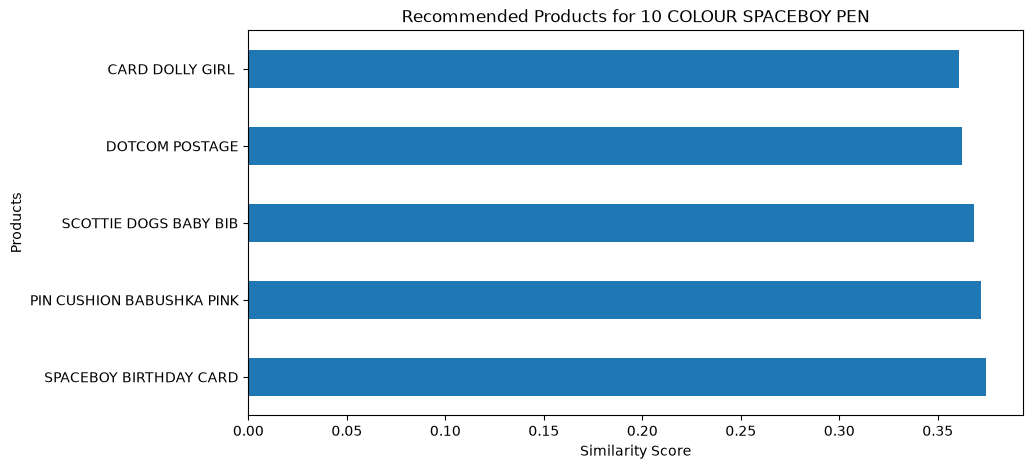

In [54]:
recommendations = recommend_products('10 COLOUR SPACEBOY PEN')

plt.figure(figsize=(10,5))
recommendations.plot(kind='barh')

plt.title('Recommended Products for 10 COLOUR SPACEBOY PEN')
plt.xlabel('Similarity Score')
plt.ylabel('Products')

plt.show()

# Business Insights

### Customer Segmentation
- Four customer segments were identified using K-Means clustering.
- High-value customers contribute a significant portion of revenue.
- Low-engagement customers require targeted marketing campaigns.

### Product Recommendations
- Collaborative filtering was used to identify similar products.
- Recommended products can improve customer engagement and increase sales.

### Business Impact
- Better customer understanding.
- Improved marketing efficiency.
- Increased cross-selling opportunities.
- Data-driven decision making.

# Project Conclusion

This project successfully analyzed customer purchasing behavior using RFM Analysis and K-Means Clustering.

Four customer segments were identified:

- VIP Customers
- Loyal Customers
- Regular Customers
- At-Risk Customers

A product recommendation engine was developed using Item-Based Collaborative Filtering and Cosine Similarity.

The proposed solution helps businesses:

- Improve customer retention
- Increase cross-selling opportunities
- Personalize marketing campaigns
- Enhance customer satisfaction

Future improvements may include real-time recommendations through a Streamlit web application.

Key Achievements:
- Cleaned and processed 397,884 transaction records.
- Segmented 4,338 customers into 4 meaningful clusters.
- Identified customer purchasing patterns using RFM metrics.
- Built a product recommendation system using collaborative filtering.

Business Impact:
- Enables targeted marketing campaigns.
- Helps improve customer retention.
- Supports personalized product recommendations.
- Increases opportunities for cross-selling and upselling.

Future Scope:
- Deploy the model using Streamlit.
- Integrate real-time recommendations.
- Use advanced recommendation algorithms for improved accuracy.